# Personalizing the chatbot by using the existing prefilled memory
- Workflow
    - START -> Chat Node -> END
- Before replying to the questions first it checks whether there exists some memory related to the question, if yes it fetches that and passes it as a context to the LLM
- Note this does not create new memories, it just uses the existing memories as context to provide personalization

In [1]:

from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain.messages import SystemMessage, HumanMessage
from langchain_core.runnables import RunnableConfig

/Users/ritumalage/Documents/my_github/Notes/.venv_langgraph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Creating a memory store
- An existing prefilled memory store will be used

In [2]:
store = InMemoryStore()

namespace = ("user", "user1", "details")

# Creating memory manually 
store.put(namespace=namespace, key="profile1", value = {"data": "Name: John"})
store.put(namespace=namespace, key="profile2", value = {"data": "He is a Computer science professor"})
store.put(namespace=namespace, key="preference1", value = {"data": "He likes python"})
store.put(namespace=namespace, key="preference2", value = {"data": "He wants an example to be associated while explaining"})
store.put(namespace=namespace, key="subject", value = {"data": "Good at DSA, DAA"})

# Defining the system prompt

In [3]:
SYSTEM_PROMPT_TEMPLATE = """
You are an assistant with memory capabilities. If user specific memory is available, use it to personalize the response based on what you know about the user

Your goal is provide relevant, friendly, tailored assistance, that reflects users preferences and past interactions
If the users name or any personal information is available, personalize the response by 
- Always addressing the user by Name when appropriate like (Hi John,..)
- Try providing examples using the existing working projects so that the user will be able to grasp even better

The users memory is {user_memory}. This may be empty
"""

In [4]:
model = ChatGroq(model = "qwen/qwen3-32b") 

# Building the Chat Node
- Usually chat Node would have only 1 input i.e. the state but now 3 inputs have to be passed
    1. state
    2. config
        - Type: RunnableConfig
        - As while fetching the memory user id is required and this is stored in the config 
    3. store
        - Type: BaseConfig
        - This is needed so that the node has the information about the memory

In [5]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    # Fetching the memory realted to the user
    users_namespace = ("user", user_id, "details")
    items = store.search(users_namespace)


    # If memory exists then convert all the memories into a single str blob so that it can be directly passed to the LLM
    if items:
        users_context = ""
        # The values of the memory is stored inside value.data
        # If there are N memories its values are seperated by a newline
        for item in items:
            users_context = users_context + "\n" + item.value.get("data")
        
    else:
        users_context = ""

    # .format is used to replace the placeholders with the actual value
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_memory = users_context)

    system_message = SystemMessage(content = system_prompt)


    # Pass both the memory and the messages
    response = model.invoke([system_message] + state["messages"])

    return {"messages": [response]}

# Building the graph
- While compiling the graph the store must be passed

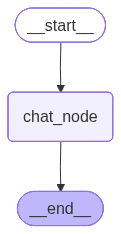

In [6]:
graph = StateGraph(MessagesState)

graph.add_node("chat_node", chat_node)


graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)


workflow = graph.compile(store=store)
workflow

In [7]:
config = {"configurable": {"user_id": "user1"}}

workflow.invoke({"messages": [HumanMessage(content="Can you explain what is LangGraph?")]},
    config
)


{'messages': [HumanMessage(content='Can you explain what is LangGraph?', additional_kwargs={}, response_metadata={}, id='667d31f4-03df-4302-b332-5b1ab33319a4'),
  AIMessage(content='<think>\nOkay, John is asking about LangGraph. Let me start by recalling what LangGraph is. It\'s a framework for building stateful, workflow-based applications for LLM agents. Since John is a computer science professor who likes Python and is good with DSA/DAA, I should connect it to concepts he\'s familiar with.\n\nHe wants an example associated with his projects. Maybe I can use a Python-based example. LangGraph allows creating graphs where nodes are functions, so comparing it to a graph data structure he\'s taught could help. I should mention state management since that\'s part of LangGraph\'s features. Also, since he likes Python, highlighting integration with Python tools or libraries would be good. Need to explain how it helps in structuring complex workflows for LLMs, maybe with a simple example. Ma

- Now you can see that the response is tailored with respect to the users preferences and there is personalization